# Geometry & Visualization for SatSim scenes

**ADR-0001 Action Item 2 / ADR-0002 Notebook 2.** This notebook answers a narrow, practical
question: *before* committing to an expensive render, how do we sanity-check the **scene geometry**
(where the sensor points, whether the target is actually up and in the field of view)?

Two paths are examined:

1. **SatSim's native CZML export** (`sim.save_czml`) → **Cesium** / SatViz. We verify what the export
   actually contains and how portable it is.
2. A **Python-native fallback** (**Skyfield** + **poliastro**) that runs right here in the notebook —
   ground track, look-angles, and orbital elements from the same TLE.

> **Scope.** Geometry/visualization only, decoupled from the radiometric chain (ADR §Decision.4). No
> synphot, no DIRSIG, no band integration — those are later notebooks. We reuse the SatSim config
> style from Notebook 1.

**Headline findings** (details and evidence below):

- SatSim writes a valid **CZML 1.0** document to `satsim.czml`: a clock, the observer (ground or space
  station) with a **time-varying rectangular sensor cone**, and each target as an **inertial (ECI)
  position path**.
- Positions / paths / billboards / clock are **standard CZML** and load in vanilla CesiumJS. The sensor
  cone uses the **AGI `agi_rectangularSensor` extension**, which needs Cesium ion's sensors SDK to
  render — plain CesiumJS silently ignores it.
- **SatViz / `satsimjs` does not document a CZML loader**; its scenario format is a custom command
  schema. So SatSim-CZML → SatViz is *not* a drop-in path and is left unconfirmed; vanilla CesiumJS is
  the reliable CZML consumer, and the Skyfield/poliastro fallback is what we can actually drive from
  Python today.

---


## 1. Generate a scene with CZML export

We build a compact SatSim config (a Maui ground site rate-tracking the ISS, same canonical TLE as
Notebook 1) and set `sim.save_czml = True`. `sim.czml_samples` controls how many position samples the
target path gets (default 10).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, json
from satsim import gen_multi

TLE1 = "1 25544U 98067A   08264.51782528 -.00002182  00000-0 -11606-4 0  2927"
TLE2 = "2 25544  51.6416 247.4627 0006703 130.5360 325.0288 15.72125391563537"

ssp = {
    "version": 1,
    "sim": {"mode": "fftconv2p", "spatial_osf": 1, "temporal_osf": 1, "padding": 20,
            "samples": 1, "save_jpeg": False, "save_movie": False,
            "save_czml": True, "czml_samples": 30},
    "fpa": {"height": 128, "width": 128, "y_fov": 1.0, "x_fov": 1.0, "dark_current": 0.3,
            "gain": 1.0, "bias": 0.0, "zeropoint": 20.6663,
            "a2d": {"response": "linear", "fwc": 100000, "gain": 1.5, "bias": 1500},
            "noise": {"read": 9.0, "electronic": 0.0}, "psf": {"mode": "gaussian", "eod": 0.15},
            "time": {"exposure": 5.0, "gap": 2.5}, "num_frames": 4},
    "background": {"galactic": 19.5},
    "geometry": {"time": [2008, 9, 20, 4, 0, 0.0],
                 "site": {"lat": 20.7, "lon": -156.3, "alt": 3.0, "name": "Maui-GS",
                          "gimbal": {"rotation": 0.0},
                          "track": {"mode": "rate", "tle": [TLE1, TLE2], "name": "ISS"}},
                 "stars": {"mode": "bins",
                           "mv": {"bins": [10, 12, 14, 16], "density": [5, 20, 60]},
                           "motion": {"mode": "none"}},
                 "obs": {"mode": "list",
                         "list": [{"mode": "tle", "tle": [TLE1, TLE2], "mv": 8.0, "name": "ISS"}]}},
}

out = os.path.abspath("output")
os.makedirs(out, exist_ok=True)
gen_multi(ssp, output_dir=out, folder_name="czml_run")

czml_path = os.path.join(out, "czml_run", "satsim.czml")
print("Wrote:", czml_path, "|", os.path.getsize(czml_path), "bytes")

Wrote: C:\Users\kevin.kearney\code\SatSim\notebooks\output\czml_run\satsim.czml | 5844 bytes


## 2. What's actually in the CZML

CZML is a JSON array of *packets*. Let's enumerate them and see how SatSim maps a scene onto Cesium
primitives. (Source of truth: `satsim/io/czml.py`, `save_czml` + `CZMLExtractor`.)

In [2]:
doc = json.load(open(czml_path))
print("packet count:", len(doc), "\n")
for p in doc:
    pid = str(p.get("id"))[:22]
    keys = [k for k in p if k != "id"]
    extra = ""
    pos = p.get("position")
    if isinstance(pos, dict):
        if "cartesian" in pos:
            extra += f"  position={len(pos['cartesian'])//4} samples, frame={pos.get('referenceFrame')}"
        if "reference" in pos:
            extra += f"  position->{pos['reference']}"
    if "agi_rectangularSensor" in p:
        s = p["agi_rectangularSensor"]
        import math
        extra += f"  SENSOR halfangles=({math.degrees(s['xHalfAngle']):.2f} deg, {math.degrees(s['yHalfAngle']):.2f} deg)"
    print(f"  id={pid:22s} keys={keys}{extra}")

packet count: 4 

  id=document               keys=['version', 'name', 'clock']
  id=GS0                    keys=['availability', 'position', 'billboard', 'label']  position=0 samples, frame=None
  id=GS0_FOV                keys=['parent', 'position', 'orientation', 'agi_rectangularSensor']  position->GS0#position  SENSOR halfangles=(0.50 deg, 0.50 deg)
  id=0                      keys=['name', 'availability', 'position', 'billboard', 'label', 'path']  position=30 samples, frame=INERTIAL


### Packet-by-packet

| packet | Cesium role | notes |
|---|---|---|
| `document` | preamble | CZML `version` "1.0" + a **clock** (`interval`, `currentTime`, `multiplier` 60×). Drives the timeline scrubber. |
| `GS<n>` | the observer | ground site → **static ECEF** `position` + billboard + label. A *space*-based observer instead gets a time-sampled **inertial** position and a path. |
| `GS<n>_FOV` | sensor cone | child of the observer; `orientation` is a **quaternion time series** pointing at the target, and `agi_rectangularSensor` gives the FOV as `xHalfAngle`/`yHalfAngle` with a **time-varying `radius`** = slant range to target. |
| `<int>` | each target | `position` is **inertial (ECI/J2000)** `cartesian`, Lagrange-interpolated, with a `path`, billboard and label. One packet per `geometry.obs.list` entry. |

Two things to internalize: the observer's pointing/FOV is encoded as a real **sensor volume**, and the
observer sits in the **fixed frame** while targets sit in the **inertial frame** — Cesium reconciles
the two, but any external consumer must honor both `referenceFrame`s.

In [3]:
# The clock preamble and a trimmed target packet, verbatim
print("--- document/clock ---")
print(json.dumps(doc[0], indent=1))
tgt = [p for p in doc if str(p.get("id")).isdigit()][0]
trimmed = dict(tgt)
trimmed["position"] = {k: (v if k != "cartesian" else v[:8] + ["...(%d more)" % (len(v)-8)])
                       for k, v in tgt["position"].items()}
print("\n--- target packet (position samples trimmed) ---")
print(json.dumps(trimmed, indent=1)[:1100])

--- document/clock ---
{
 "id": "document",
 "version": "1.0",
 "name": "document_packet",
 "clock": {
  "interval": "2008-09-20T04:00:00.000Z/2008-09-20T04:00:30.000Z",
  "currentTime": "2008-09-20T04:00:00.000000Z",
  "multiplier": 60,
  "range": "LOOP_STOP",
  "step": "SYSTEM_CLOCK_MULTIPLIER"
 }
}

--- target packet (position samples trimmed) ---
{
 "id": 0,
 "name": "ISS",
 "availability": "2008-09-20T04:00:00.000Z/2008-09-20T04:00:30.000Z",
 "position": {
  "epoch": "2008-09-20T04:00:00.000000Z",
  "interpolationAlgorithm": "LAGRANGE",
  "interpolationDegree": 3,
  "referenceFrame": "INERTIAL",
  "cartesian": [
   0.0,
   -3776689.599282425,
   1832988.0618328354,
   -5271569.940746087,
   1.0344827586205205,
   -3779767.330798588,
   1825667.890462979,
   -5271909.038764944,
   "...(112 more)"
  ]
 },
 "billboard": {
  "image": "",
  "show": true
 },
 "label": {
  "show": false,
  "text": "ISS",
  "font": "16pt Lucida Console",
  "style": "FILL",
  "fillColor": {
   "rgba": [
  

### Portability: standard CZML vs. AGI extension

- **Standard CZML** (renders in *vanilla* CesiumJS): `clock`, `position` (both frames), `path`,
  `billboard`, `label`, `orientation`.
- **AGI extension**: `agi_rectangularSensor`. This is part of Cesium **ion's** sensors package
  (formerly AGI). Plain CesiumJS **silently ignores** it — you still get the satellite, its path, and
  the ground station, but **no sensor cone** unless the ion sensors SDK is loaded.

So the export degrades gracefully: the essential geometry is portable; only the FOV-cone eye-candy is
gated behind ion.

## 3. Loading into Cesium / SatViz

We can't run a browser here, but the mechanics are unambiguous. **Vanilla CesiumJS** consumes the file
directly:

```js
// Standalone CesiumJS (positions, paths, billboards, clock all render;
// the agi_rectangularSensor cone requires the Cesium ion sensors SDK).
const viewer = new Cesium.Viewer("cesiumContainer");
Cesium.CzmlDataSource.load("satsim.czml").then(ds => {
  viewer.dataSources.add(ds);
  viewer.trackedEntity = ds.entities.getById("0");   // follow the target
});
```

**SatViz / `satsimjs`** is the tool ADR-0001 names as the *primary* visualization bridge, and this is
where the ADR's caution ("integration specifics are not yet confirmed and must be verified against
source") bites:

- `satsimjs` **is** built on CesiumJS, but its documented scenario input is a **custom command schema**
  (`schemas/command/v1/`, `docs/commands.md`), **not** CZML. No CZML loader/import is documented in the
  repo.
- Therefore **SatSim-CZML → SatViz is not a drop-in path.** Options, in rough order of effort:
  1. Use **plain CesiumJS** with `CzmlDataSource` (works today for everything except the ion sensor cone).
  2. Load the CZML through Cesium *inside* a SatViz viewer if SatViz exposes the underlying
     `Cesium.Viewer` (unverified — needs a source check of `createViewer()`).
  3. Write a small **CZML → satsimjs-command** converter (only if SatViz-specific features are needed).

> **Assumption logged:** I did not clone/run `satsimjs` (JS toolchain, out of scope for this Python
> session). The "no CZML loader" finding is from its published README/docs, not an exhaustive source
> audit — flagged for confirmation when the visualization front-end is actually stood up (ADR AI9).


## 4. Python-native fallback: Skyfield + poliastro

The fallback the ADR names (Skyfield / poliastro) is what we can actually **drive from Python now**, and
it does the one job that matters most before a render: **confirm the target is where you think it is.**
Everything below propagates the *same TLE* SatSim used.

In [4]:
import numpy as np
from skyfield.api import load, wgs84, EarthSatellite

ts = load.timescale()
sat = EarthSatellite(TLE1, TLE2, "ISS", ts)
site = wgs84.latlon(20.7, -156.3, elevation_m=3000)   # Maui-GS, matches the SatSim config

# One orbital period (~92 min) at 30 s cadence, starting at the scene epoch.
mins = np.arange(0, 93, 0.5)
tvec = ts.utc(2008, 9, 20, 4, mins)
geo = sat.at(tvec)
sub = wgs84.subpoint(geo)
lat, lon = sub.latitude.degrees, sub.longitude.degrees
print("Propagated", len(mins), "steps over ~1 orbit.")

Propagated 186 steps over ~1 orbit.


### 4a. Ground track

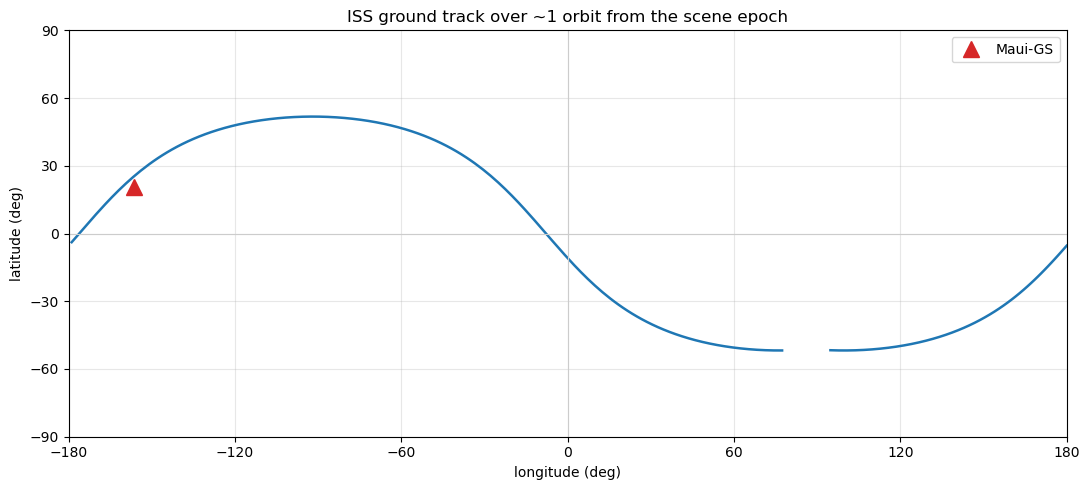

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
# split the track where it wraps across the +/-180 dateline so we don't draw a seam
d = np.abs(np.diff(lon))
seg = np.where(d > 180)[0] + 1
for chunk in np.split(np.arange(len(lon)), seg):
    ax.plot(lon[chunk], lat[chunk], color="tab:blue", lw=1.8)
ax.plot(-156.3, 20.7, "^", color="tab:red", ms=12, label="Maui-GS")
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xticks(range(-180, 181, 60)); ax.set_yticks(range(-90, 91, 30))
ax.axhline(0, color="0.8", lw=0.8); ax.axvline(0, color="0.8", lw=0.8)
ax.set_xlabel("longitude (deg)"); ax.set_ylabel("latitude (deg)")
ax.set_title("ISS ground track over ~1 orbit from the scene epoch")
ax.legend(loc="upper right"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 4b. Is the target even visible? (the check that catches bad geometry)

SatSim, by default, renders the target from its magnitude **regardless of whether it is above the
horizon or sunlit** (Notebook 1's silent-failure #5). The geometry check below is exactly how you catch
that. We compute the topocentric altitude of the target at the scene epoch and over the orbit.

In [6]:
topo = (sat - site).at(tvec)
alt, az, dist = topo.altaz()

t0 = ts.utc(2008, 9, 20, 4, 0, 0)
alt0, az0, d0 = (sat - site).at(t0).altaz()
print(f"At the SCENE EPOCH (2008-09-20 04:00 UTC):")
print(f"  altitude = {alt0.degrees:+.1f} deg   (negative => BELOW the horizon)")
print(f"  azimuth  = {az0.degrees:.1f} deg,  slant range = {d0.km:.0f} km")
print(f"  fraction of the orbit spent above the horizon: {(alt.degrees > 0).mean():.0%}")
print()
print("=> At this epoch the ISS is well below the local horizon: the Notebook-1 frame that")
print("   'rendered' it was geometrically impossible. This is the sanity check doing its job.")

At the SCENE EPOCH (2008-09-20 04:00 UTC):
  altitude = -58.0 deg   (negative => BELOW the horizon)
  azimuth  = 221.8 deg,  slant range = 11224 km
  fraction of the orbit spent above the horizon: 11%

=> At this epoch the ISS is well below the local horizon: the Notebook-1 frame that
   'rendered' it was geometrically impossible. This is the sanity check doing its job.


### 4c. Find a *real* visible pass and plot its sky track

To show a meaningful look-angle plot we let Skyfield **find** an actual pass over Maui within 24 h of
the epoch (rise/culminate/set above 10° elevation), then plot that pass in azimuth/elevation.

Best pass: culminates at 2008-09-20 04:31:12 UTC, peak elevation 43.1 deg


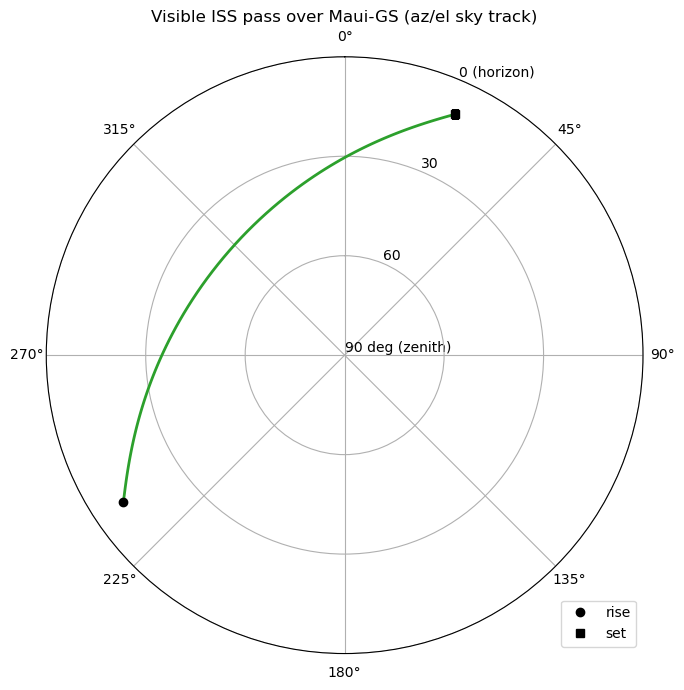

In [7]:
t_lo = ts.utc(2008, 9, 20, 4, 0, 0)
t_hi = ts.utc(2008, 9, 21, 4, 0, 0)
t_ev, ev = sat.find_events(site, t_lo, t_hi, altitude_degrees=10.0)

# group into (rise, culminate, set) triples and keep the highest-culmination pass
passes = []
cur = {}
for t, e in zip(t_ev, ev):
    cur[e] = t
    if e == 2 and 0 in cur and 1 in cur:      # a complete rise->culm->set
        peak = (sat - site).at(cur[1]).altaz()[0].degrees
        passes.append((peak, cur[0], cur[1], cur[2]))
        cur = {}
peak, t_rise, t_culm, t_set = max(passes)
print(f"Best pass: culminates at {t_culm.utc_strftime('%Y-%m-%d %H:%M:%S')} UTC, peak elevation {peak:.1f} deg")

tp = ts.linspace(t_rise, t_set, 120)
altp, azp, _ = (sat - site).at(tp).altaz()

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)              # compass: N up, E right
ax.plot(np.radians(azp.degrees), 90 - altp.degrees, color="tab:green", lw=2)
ax.plot(np.radians(azp.degrees[0]), 90 - altp.degrees[0], "o", color="k", label="rise")
ax.plot(np.radians(azp.degrees[-1]), 90 - altp.degrees[-1], "s", color="k", label="set")
ax.set_rmax(90); ax.set_rticks([0, 30, 60, 90])
ax.set_yticklabels(["90 deg (zenith)", "60", "30", "0 (horizon)"])
ax.set_title("Visible ISS pass over Maui-GS (az/el sky track)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

### 4d. Orbital elements via poliastro

For an orbit-mechanics view (rather than an observer-centric one), poliastro turns the TLE's
instantaneous state into a classical two-body orbit. We take the ECI state from Skyfield at epoch and
build a poliastro `Orbit`, then print the osculating elements.

> Note: poliastro 0.17 runs against this env's astropy 5.3, but is archived upstream — fine for
> R&D-stage geometry checks; not something to build production tooling on.

In [8]:
from astropy import units as u
from astropy.time import Time
from poliastro.bodies import Earth
from poliastro.twobody import Orbit

g0 = sat.at(t0)
r = g0.position.km          # GCRS (ECI) position
v = g0.velocity.km_per_s    # GCRS (ECI) velocity
orb = Orbit.from_vectors(Earth, r * u.km, v * (u.km / u.s), epoch=Time(t0.utc_iso()))

print("Osculating classical elements at epoch:")
print(f"  semi-major axis a   = {orb.a:.1f}")
print(f"  eccentricity   e    = {orb.ecc:.5f}")
print(f"  inclination    i    = {orb.inc.to(u.deg):.3f}")
print(f"  RAAN           Omega= {orb.raan.to(u.deg):.3f}")
print(f"  arg. perigee   omega= {orb.argp.to(u.deg):.3f}")
print(f"  true anomaly   nu   = {orb.nu.to(u.deg):.3f}")
print(f"  period              = {orb.period.to(u.min):.2f}")
print(f"  altitude (r - R_earth) approx = {(orb.r_p - Earth.R):.0f} perigee / {(orb.r_a - Earth.R):.0f} apogee")

Osculating classical elements at epoch:


  semi-major axis a   = 6725.5 km
  eccentricity   e    = 0.00205
  inclination    i    = 51.576 deg
  RAAN           Omega= 249.137 deg
  arg. perigee   omega= 100.045 deg
  true anomaly   nu   = 166.826 deg
  period              = 91.48 min
  altitude (r - R_earth) approx = 334 km perigee / 361 km apogee


## 5. Findings vs. the ADR's assumptions

What ADR-0001 assumed about visualization, and what the source/experiments here actually show:

| ADR-0001 statement | Verified? | Finding |
|---|---|---|
| "Bridge to Cesium is SatSim's native CZML export (`save_czml`)." | ✅ | Confirmed. `sim.save_czml` writes `satsim.czml`, a valid CZML 1.0 doc (clock + observer + sensor cone + inertial target paths). Source: `satsim/io/czml.py`. |
| "SatViz/Cesium integration specifics are not yet confirmed and must be verified against source before being relied on." | ✅ (and warranted) | `satsimjs`/SatViz documents a **custom command schema, not a CZML loader**. SatSim-CZML → SatViz is **not** a drop-in; vanilla CesiumJS is the reliable CZML consumer. |
| "Skyfield + poliastro (fallback) — scene-geometry visualization." | ✅ | Both import and run in `satsim-env`. Skyfield gives ground track, look-angles, and pass prediction; poliastro gives osculating elements. This fallback runs **today, in Python**, with no browser. |
| (implicit) the exported geometry is fully standard | ⚠️ partial | The **sensor cone** uses the **AGI `agi_rectangularSensor`** ion extension; plain CesiumJS ignores it. Everything else is standard CZML. |

### Recommendation for Action Item 9 (when visualization is actually stood up)
- Treat **CZML → vanilla CesiumJS** as the baseline, reliable path.
- Treat **SatViz/`satsimjs`** as *unconfirmed*: before relying on it, verify from its source whether
  `createViewer()` exposes the underlying `Cesium.Viewer` (so a `CzmlDataSource` can be added directly),
  or whether a CZML→command-schema converter is needed.
- For **day-to-day geometry sanity checks during R&D**, prefer the **Skyfield fallback** — it is the
  fastest way to catch the errors SatSim will not (target below horizon / not sunlit / outside FOV),
  and it needs no web toolchain.

### New quirk found this notebook
- **SatSim renders geometrically impossible frames.** At the Notebook-1 epoch the target is 58° below
  the Maui horizon, yet SatSim produced a "detection." Always geometry-check a scene (§4b) before
  trusting a render — the image alone will not warn you.
